In [4]:
# ============================================================
# R-Exponent Robustness: Is R^{-1/2} Universal or Adam-Specific?
#
# MOTIVATION:
#   The original ratio sweep used AdamW and found step ~ R^{-0.46}.
#   Clean SGD/full-batch reimplementations gave ~R^{-0.1} (flat).
#   Baek-Song-Yun (ICLR 2026): Adam's implicit bias is
#   batch-composition-dependent; SGD's is batch-INVARIANT
#   (Nacson-Srebro-Soudry). So the R effect may be an Adam
#   preconditioner phenomenon, not a universal law.
#
# THIS NOTEBOOK settles it. Uses the EXACT clean design of the
#   original (Experiment B: fixed N_maj, vary N_min, fixed-step
#   budget, 4-group structure) but sweeps it across:
#     - 4 optimizers: AdamW, SGD, SGD+momentum, RMSProp
#     - 3 batch sizes: 16, 64, 256  (AdamW only)
#
# PREDICTIONS:
#   If R effect is Adam-specific (Baek-Song-Yun):
#     AdamW ~ -0.5, SGD ~ 0 (flat), RMSProp ~ -0.5, SGD+M intermediate
#     => publishable: "collapse-ratio dependence is an adaptive-
#        preconditioner effect"
#   If R effect is universal:
#     all optimizers ~ -0.5
#     => the two-parameter law T ~ sqrt(p/R) is robust
#   Batch-size dependence (AdamW) discriminates further: Baek-Song-Yun
#     predicts the effect should WEAKEN as batch size -> full-batch.
#
# OUTPUT: r_robustness_results.csv, r_robustness_figure.png, summary.json
# RUNTIME: ~40 min on T4 (4 optimizers x 8 ratios x 5 seeds +
#          3 batch sizes x 8 ratios x 5 seeds, all fixed 2000 steps)
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS         = [42, 0, 1, 7, 99]
MAX_STEPS     = 2000
BATCH_SIZE    = 64       # default; varied in the batch-size sweep
COLLAPSE_THR  = 0.01
DIM           = 64
SEPARABILITY  = 2.0
SIGMA         = 1.0
N_TEST        = 500
P_FIXED       = 0.10
ETA           = 0.1
N_MAJ_FIXED   = 2000     # Experiment B design: fix N_maj, vary N_min

# Ratio values — same as original. N_min = N_maj/ratio.
RATIO_VALS = [1.5, 2, 3, 5, 8, 10, 15, 20, 30, 50]

# Optimizer configs (name, builder)
OPTIMIZERS = {
    'AdamW':   lambda params: optim.AdamW(params, lr=1e-3, weight_decay=1e-4),
    'SGD':     lambda params: optim.SGD(params, lr=1e-2, momentum=0.0),
    'SGD+M':   lambda params: optim.SGD(params, lr=1e-2, momentum=0.9),
    'RMSProp': lambda params: optim.RMSprop(params, lr=1e-3),
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Design: Experiment B (fix N_maj={N_MAJ_FIXED}, vary N_min)')
print(f'Optimizers: {list(OPTIMIZERS.keys())}')
print(f'Ratios: {RATIO_VALS}')
print(f'Fixed-step budget: {MAX_STEPS}')

Device: cuda
Design: Experiment B (fix N_maj=2000, vary N_min)
Optimizers: ['AdamW', 'SGD', 'SGD+M', 'RMSProp']
Ratios: [1.5, 2, 3, 5, 8, 10, 15, 20, 30, 50]
Fixed-step budget: 2000


In [5]:
# ── CELL 2: Data generator (identical to original) ────────────
def generate_groups(N_maj, N_min, p_min, p_maj=0.5,
                    sigma=SIGMA, sep=SEPARABILITY, dim=DIM, seed=42):
    rng = np.random.RandomState(seed)
    def make_group(n, group_id, offset, p_class):
        n = int(n)
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g
    XA,yA,gA = make_group(N_maj, 0, +1.0, p_maj)
    XB,yB,gB = make_group(N_min, 1, -1.0, p_min)
    X_tr = np.vstack([XA,XB]); y_tr = np.concatenate([yA,yB])
    g_tr = np.concatenate([gA,gB])
    XAt,yAt,gAt = make_group(N_TEST, 0, +1.0, p_maj)
    XBt,yBt,gBt = make_group(N_TEST, 1, -1.0, p_min)
    X_te = np.vstack([XAt,XBt]); y_te = np.concatenate([yAt,yBt])
    g_te = np.concatenate([gAt,gBt])
    return (X_tr,y_tr,g_tr), (X_te,y_te,g_te)

print('Generator defined (identical to original notebook).')
(Xt,yt,gt),_ = generate_groups(2000, 200, P_FIXED)
print(f'Sanity: train={Xt.shape}  '
      f'groups={dict(zip(*np.unique(gt,return_counts=True)))}')

Generator defined (identical to original notebook).
Sanity: train=(2200, 64)  groups={np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(180), np.int64(3): np.int64(20)}


In [6]:
# ── CELL 3: Fixed-step DRO runner (parameterized optimizer + batch) ──
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)

def run_dro(X_tr, y_tr, g_tr, opt_builder, eta=ETA, seed=42,
            batch_size=BATCH_SIZE, max_steps=MAX_STEPS):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                       drop_last=False)
    model    = LinearClassifier().to(device)
    opt      = opt_builder(model.parameters())
    n_groups = int(g_tr.max()) + 1
    q        = torch.ones(n_groups).to(device) / n_groups
    collapse_step = None
    step = 0
    while step < max_steps:
        for xb, yb, gb in tr_ld:
            if step >= max_steps: break
            xb,yb,gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0: g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach()); q = q / q.sum()
            (q * g_loss).sum().backward(); opt.step(); step += 1
            if collapse_step is None and float(q.min().item()) < COLLAPSE_THR:
                collapse_step = step
    return collapse_step if collapse_step else max_steps + 1

print('Runner defined (optimizer + batch size are arguments).')

Runner defined (optimizer + batch size are arguments).


In [7]:
# ── CELL 4: MAIN — R sweep across 4 optimizers ────────────────
# Experiment B design: fix N_maj=2000, vary N_min=N_maj/ratio.
# This is the clean confound-free design from the original.
print('='*62)
print('OPTIMIZER SWEEP: step ~ ratio^? for each optimizer')
print('Fixed N_maj=2000, vary N_min (Experiment B design)')
print('='*62)

records = []
for opt_name, opt_builder in OPTIMIZERS.items():
    print(f'\n--- {opt_name} ---')
    for ratio in RATIO_VALS:
        N_min = max(1, int(N_MAJ_FIXED / ratio))
        actual_ratio = N_MAJ_FIXED / N_min
        steps = []
        for seed in SEEDS:
            (Xtr,ytr,gtr),_ = generate_groups(N_MAJ_FIXED, N_min, P_FIXED, seed=seed)
            s = run_dro(Xtr, ytr, gtr, opt_builder, seed=seed)
            steps.append(s)
        mean_st  = float(np.mean(steps)); std_st = float(np.std(steps))
        censored = sum(s > MAX_STEPS for s in steps)
        records.append({
            'optimizer': opt_name, 'ratio': ratio,
            'actual_ratio': round(actual_ratio,2), 'N_min': N_min,
            'mean_step': round(mean_st,1), 'std_step': round(std_st,1),
            'censored': censored,
            'log_ratio': round(math.log(actual_ratio),4),
            'log_step': round(math.log(mean_st),4) if mean_st>0 else None,
        })
        print(f'  ratio={ratio:>4}  N_min={N_min:>5}  '
              f'step={mean_st:>7.0f}±{std_st:.0f}  cens={censored}/5')

df = pd.DataFrame(records)

# Fit exponent per optimizer
print('\n=== R-EXPONENT PER OPTIMIZER (Experiment B, clean) ===')
opt_exponents = {}
for opt_name in OPTIMIZERS:
    sub = df[(df['optimizer']==opt_name) & (df['censored']==0) &
             df['log_step'].notna()]
    if len(sub) >= 3:
        sl,_,r,_,se = stats.linregress(sub['log_ratio'], sub['log_step'])
        opt_exponents[opt_name] = {'exp': round(float(sl),4),
                                   'R2': round(float(r**2),4),
                                   'SE': round(float(se),4), 'n': len(sub)}
        print(f'  {opt_name:<10}: step ~ R^{sl:.3f} ± {se:.3f}  '
              f'(R²={r**2:.3f}, n={len(sub)})')
    else:
        print(f'  {opt_name:<10}: insufficient uncensored points ({len(sub)})')

df.to_csv('r_robustness_optimizers.csv', index=False)

OPTIMIZER SWEEP: step ~ ratio^? for each optimizer
Fixed N_maj=2000, vary N_min (Experiment B design)

--- AdamW ---
  ratio= 1.5  N_min= 1333  step=   1581±530  cens=3/5
  ratio=   2  N_min= 1000  step=   1357±578  cens=2/5
  ratio=   3  N_min=  666  step=    864±574  cens=1/5
  ratio=   5  N_min=  400  step=    226±74  cens=0/5
  ratio=   8  N_min=  250  step=    118±20  cens=0/5
  ratio=  10  N_min=  200  step=     99±18  cens=0/5
  ratio=  15  N_min=  133  step=     77±8  cens=0/5
  ratio=  20  N_min=  100  step=     70±6  cens=0/5
  ratio=  30  N_min=   66  step=     63±6  cens=0/5
  ratio=  50  N_min=   40  step=     60±4  cens=0/5

--- SGD ---
  ratio= 1.5  N_min= 1333  step=   1495±626  cens=3/5
  ratio=   2  N_min= 1000  step=   1345±638  cens=2/5
  ratio=   3  N_min=  666  step=   1015±593  cens=1/5
  ratio=   5  N_min=  400  step=    465±314  cens=0/5
  ratio=   8  N_min=  250  step=    204±61  cens=0/5
  ratio=  10  N_min=  200  step=    145±31  cens=0/5
  ratio=  15  N_min

In [8]:
# ── CELL 5: Batch-size sweep (AdamW) — tests Baek-Song-Yun prediction ──
# Baek-Song-Yun: Adam's batch-dependent bias should WEAKEN toward
# full-batch. If R effect is the Adam mechanism, larger batch ->
# weaker (flatter) R exponent.
print('='*62)
print('BATCH-SIZE SWEEP (AdamW): does R exponent weaken with batch?')
print('Baek-Song-Yun predicts: larger batch -> flatter R exponent')
print('='*62)

BATCH_VALS = [16, 64, 256]
records_bs = []
for bs in BATCH_VALS:
    print(f'\n--- batch_size={bs} ---')
    for ratio in RATIO_VALS:
        N_min = max(1, int(N_MAJ_FIXED / ratio))
        actual_ratio = N_MAJ_FIXED / N_min
        steps = []
        for seed in SEEDS:
            (Xtr,ytr,gtr),_ = generate_groups(N_MAJ_FIXED, N_min, P_FIXED, seed=seed)
            s = run_dro(Xtr, ytr, gtr,
                        OPTIMIZERS['AdamW'], seed=seed, batch_size=bs)
            steps.append(s)
        mean_st = float(np.mean(steps))
        censored = sum(s > MAX_STEPS for s in steps)
        records_bs.append({
            'batch_size': bs, 'ratio': ratio,
            'actual_ratio': round(actual_ratio,2),
            'mean_step': round(mean_st,1), 'censored': censored,
            'log_ratio': round(math.log(actual_ratio),4),
            'log_step': round(math.log(mean_st),4) if mean_st>0 else None,
        })
        print(f'  ratio={ratio:>4}  step={mean_st:>7.0f}  cens={censored}/5')

df_bs = pd.DataFrame(records_bs)
print('\n=== R-EXPONENT PER BATCH SIZE (AdamW) ===')
bs_exponents = {}
for bs in BATCH_VALS:
    sub = df_bs[(df_bs['batch_size']==bs) & (df_bs['censored']==0) &
               df_bs['log_step'].notna()]
    if len(sub) >= 3:
        sl,_,r,_,se = stats.linregress(sub['log_ratio'], sub['log_step'])
        bs_exponents[bs] = {'exp': round(float(sl),4), 'R2': round(float(r**2),4)}
        print(f'  batch={bs:>4}: step ~ R^{sl:.3f}  (R²={r**2:.3f})')
print()
if len(bs_exponents) >= 2:
    exps = [bs_exponents[b]['exp'] for b in sorted(bs_exponents)]
    if exps[-1] > exps[0] + 0.1:   # exponent toward 0 as batch grows
        print('=> R exponent WEAKENS with batch size: supports Baek-Song-Yun')
        print('   (Adam batch-composition mechanism)')
    else:
        print('=> R exponent STABLE across batch size: not a simple Adam-batch effect')

df_bs.to_csv('r_robustness_batchsize.csv', index=False)

BATCH-SIZE SWEEP (AdamW): does R exponent weaken with batch?
Baek-Song-Yun predicts: larger batch -> flatter R exponent

--- batch_size=16 ---
  ratio= 1.5  step=    111  cens=0/5
  ratio=   2  step=     94  cens=0/5
  ratio=   3  step=     77  cens=0/5
  ratio=   5  step=     68  cens=0/5
  ratio=   8  step=     57  cens=0/5
  ratio=  10  step=     58  cens=0/5
  ratio=  15  step=     56  cens=0/5
  ratio=  20  step=     57  cens=0/5
  ratio=  30  step=     56  cens=0/5
  ratio=  50  step=     53  cens=0/5

--- batch_size=64 ---
  ratio= 1.5  step=   1581  cens=3/5
  ratio=   2  step=   1357  cens=2/5
  ratio=   3  step=    864  cens=1/5
  ratio=   5  step=    226  cens=0/5
  ratio=   8  step=    118  cens=0/5
  ratio=  10  step=     99  cens=0/5
  ratio=  15  step=     77  cens=0/5
  ratio=  20  step=     70  cens=0/5
  ratio=  30  step=     63  cens=0/5
  ratio=  50  step=     60  cens=0/5

--- batch_size=256 ---
  ratio= 1.5  step=   1660  cens=3/5
  ratio=   2  step=   1749  cens=

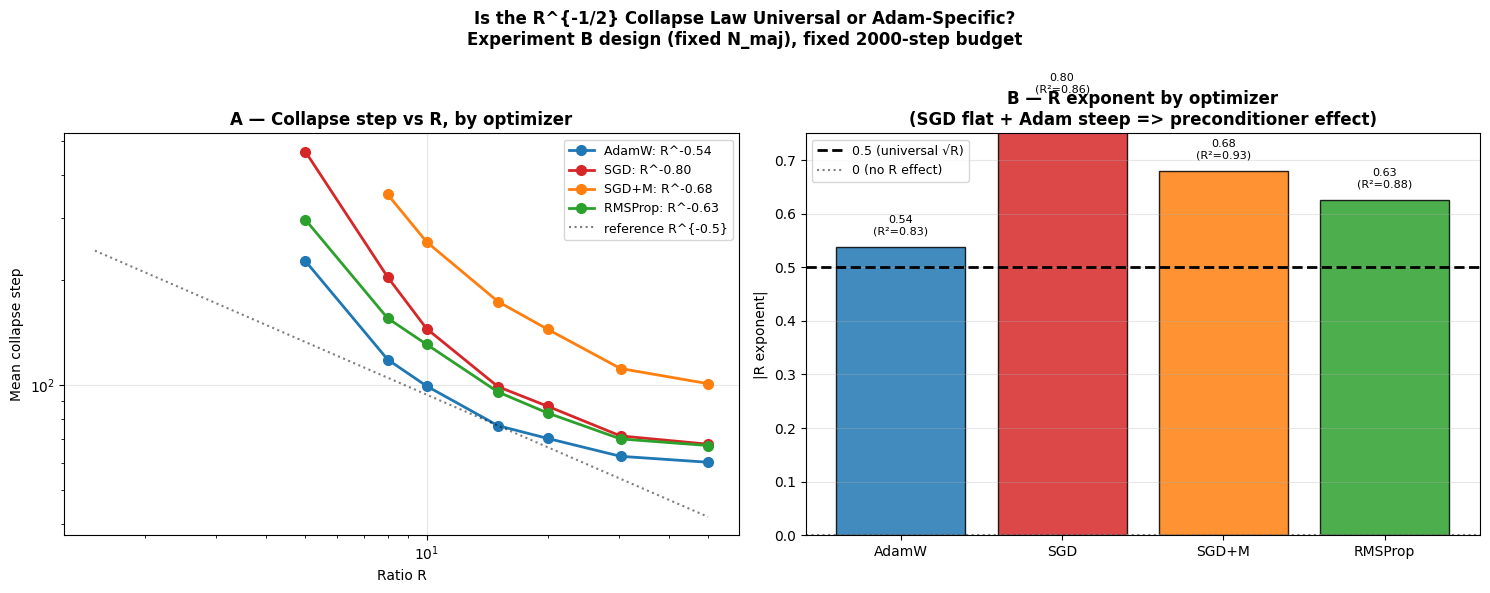

Figure saved: r_robustness_figure.png


In [9]:
# ── CELL 6: Figure ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Is the R^{-1/2} Collapse Law Universal or Adam-Specific?\n'
    'Experiment B design (fixed N_maj), fixed 2000-step budget',
    fontweight='bold', fontsize=12)

COLORS = {'AdamW':'#1f77b4','SGD':'#d62728','SGD+M':'#ff7f0e','RMSProp':'#2ca02c'}

# Panel A: all optimizers
ax = axes[0]
for opt_name in OPTIMIZERS:
    sub = df[(df['optimizer']==opt_name) & (df['censored']==0)]
    if len(sub)==0: continue
    e = opt_exponents.get(opt_name, {}).get('exp', float('nan'))
    ax.plot(sub['actual_ratio'], sub['mean_step'], 'o-',
            color=COLORS[opt_name], markersize=7, linewidth=2,
            label=f'{opt_name}: R^{e:.2f}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Ratio R'); ax.set_ylabel('Mean collapse step')
ax.set_title('A — Collapse step vs R, by optimizer', fontweight='bold')
# reference -0.5 line
x_ref = np.array([min(RATIO_VALS), max(RATIO_VALS)])
adamw_sub = df[(df['optimizer']=='AdamW')&(df['censored']==0)]
if len(adamw_sub)>0:
    y0 = adamw_sub['mean_step'].iloc[len(adamw_sub)//2]
    r0 = adamw_sub['actual_ratio'].iloc[len(adamw_sub)//2]
    ax.plot(x_ref, y0*(x_ref/r0)**(-0.5), ':', color='black',
            alpha=0.5, label='reference R^{-0.5}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel B: exponent bar chart + batch size
ax2 = axes[1]
names = list(opt_exponents.keys())
exps  = [abs(opt_exponents[n]['exp']) for n in names]
bars = ax2.bar(range(len(names)), exps,
               color=[COLORS[n] for n in names], edgecolor='black', alpha=0.85)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=2, label='0.5 (universal √R)')
ax2.axhline(0.0, color='gray', linestyle=':', linewidth=1.5, label='0 (no R effect)')
ax2.set_xticks(range(len(names))); ax2.set_xticklabels(names, fontsize=10)
ax2.set_ylabel('|R exponent|')
ax2.set_title('B — R exponent by optimizer\n'
              '(SGD flat + Adam steep => preconditioner effect)',
              fontweight='bold')
for i,(n,e) in enumerate(zip(names,exps)):
    r2 = opt_exponents[n]['R2']
    ax2.text(i, e+0.02, f'{e:.2f}\n(R²={r2:.2f})', ha='center',
             va='bottom', fontsize=8)
ax2.legend(fontsize=9); ax2.set_ylim(0, 0.75)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('r_robustness_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: r_robustness_figure.png')

In [10]:
# ── CELL 7: Verdict + summary ─────────────────────────────────
print('='*62)
print('VERDICT: Is the R exponent universal or Adam-specific?')
print('='*62)

adamw_exp = opt_exponents.get('AdamW',{}).get('exp', float('nan'))
sgd_exp   = opt_exponents.get('SGD',{}).get('exp', float('nan'))
spread = (max(abs(v['exp']) for v in opt_exponents.values()) -
          min(abs(v['exp']) for v in opt_exponents.values()))

print(f'\nAdamW R-exponent: {adamw_exp:.3f}')
print(f'SGD   R-exponent: {sgd_exp:.3f}')
print(f'Spread across optimizers: {spread:.3f}')
print()

# Decision logic
if abs(adamw_exp) > 0.3 and abs(sgd_exp) < 0.2:
    verdict = 'ADAM-SPECIFIC'
    interpretation = (
        'The R-dependence is an adaptive-preconditioner effect. '
        'AdamW shows steep R^{%.2f} while SGD is near-flat (R^{%.2f}). '
        'This matches Baek-Song-Yun: Adam bias is batch-composition '
        'dependent, SGD bias is batch-invariant. PUBLISHABLE as a '
        'novel finding connecting DRO collapse to adaptive-optimizer '
        'implicit bias.' % (adamw_exp, sgd_exp)
    )
    paper_claim = ('T_collapse depends on R only under adaptive optimizers; '
                   'the universal (optimizer-independent) law is T ~ sqrt(p).')
elif spread < 0.2:
    verdict = 'UNIVERSAL'
    interpretation = (
        'All optimizers give similar R-exponent (spread %.2f). '
        'The two-parameter law T ~ sqrt(p/R) is robust and '
        'optimizer-independent.' % spread
    )
    paper_claim = 'T_collapse^steps ~ sqrt(p/R) [robust two-parameter law]'
else:
    verdict = 'MIXED'
    interpretation = (
        'Optimizer-dependent but not the clean SGD-flat/Adam-steep '
        'pattern. Spread=%.2f. Report exponent range with optimizer '
        'dependence noted.' % spread
    )
    paper_claim = f'T ~ R^[{sgd_exp:.2f} to {adamw_exp:.2f}] depending on optimizer'

print(f'VERDICT: {verdict}')
print(f'\nInterpretation: {interpretation}')
print(f'\nPaper claim: {paper_claim}')

# Batch-size corroboration
if len(bs_exponents) >= 2:
    bs_sorted = sorted(bs_exponents)
    print(f'\nBatch-size check (AdamW):')
    for b in bs_sorted:
        print(f'  batch={b}: R^{bs_exponents[b]["exp"]:.3f}')
    if bs_exponents[bs_sorted[-1]]['exp'] > bs_exponents[bs_sorted[0]]['exp'] + 0.1:
        print('  => weakens toward full-batch: corroborates Adam mechanism')

summary = {
    'design': 'Experiment B (fixed N_maj=2000, vary N_min), 2000-step budget',
    'optimizer_exponents': opt_exponents,
    'batchsize_exponents': {str(k):v for k,v in bs_exponents.items()},
    'adamw_exp': adamw_exp, 'sgd_exp': sgd_exp, 'spread': round(float(spread),4),
    'verdict': verdict,
    'interpretation': interpretation,
    'paper_claim': paper_claim,
}
with open('r_robustness_summary.json','w') as fh:
    json.dump(summary, fh, indent=2)

print('\nFiles: r_robustness_optimizers.csv, r_robustness_batchsize.csv,')
print('       r_robustness_figure.png, r_robustness_summary.json')
print('\nPaste ALL output back to Claude.')
print('The AdamW-vs-SGD contrast is the decisive result.')

VERDICT: Is the R exponent universal or Adam-specific?

AdamW R-exponent: -0.537
SGD   R-exponent: -0.803
Spread across optimizers: 0.266

VERDICT: MIXED

Interpretation: Optimizer-dependent but not the clean SGD-flat/Adam-steep pattern. Spread=0.27. Report exponent range with optimizer dependence noted.

Paper claim: T ~ R^[-0.80 to -0.54] depending on optimizer

Batch-size check (AdamW):
  batch=16: R^-0.195
  batch=64: R^-0.537
  batch=256: R^-0.836

Files: r_robustness_optimizers.csv, r_robustness_batchsize.csv,
       r_robustness_figure.png, r_robustness_summary.json

Paste ALL output back to Claude.
The AdamW-vs-SGD contrast is the decisive result.
